# Tiền xử lý dữ liệu (Data Preprocessing)
Trong phần này, chúng ta sẽ làm sạch bộ dữ liệu chất lượng không khí của 63 tỉnh thành:
1. Nhập thư viện và tải dữ liệu.
2. Xử lý dữ liệu khuyết thiếu (Missing Values) - đặc biệt là cột `Region` (Vùng miền).
3. Lọc bỏ các giá trị bất thường (Outliers & Anomalies) do lỗi cảm biến.
4. Trích xuất đặc trưng (Feature Engineering) cho thời gian.
5. Xuất dữ liệu sạch.


## 1. Nhập thư viện và tải dữ liệu

In [3]:
from IPython import display
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Tùy chỉnh hiển thị
pd.set_option('display.max_columns', None)
sns.set_theme(style="whitegrid")

# 1. Load dữ liệu
file_path = '../data/raw/vietnam_air_quality_dataset.csv'
print("Đang đọc dữ liệu, vui lòng đợi (1.3 triệu dòng)...")
df = pd.read_csv(file_path)

print(f"Kích thước ban đầu: {df.shape}")
df.head()


Đang đọc dữ liệu, vui lòng đợi (1.3 triệu dòng)...
Kích thước ban đầu: (1388016, 12)


,Timestamp,Code,Province,Region,AQI,PM2.5 (µg/m³),PM10 (µg/m³),CO (µg/m³),NO2 (µg/m³),SO2 (µg/m³),O3 (µg/m³),Dust (µg/m³)
0,2024-01-01 00:00:00,51,An Giang,NaN,57,28.6,44.1,392.0,10.1,13.7,58.0,0.0
1,2024-01-01 01:00:00,51,An Giang,NaN,56,23.9,37.5,348.0,9.6,12.8,53.0,0.0
2,2024-01-01 02:00:00,51,An Giang,NaN,55,19.7,31.2,315.0,9.5,11.8,48.0,0.0
3,2024-01-01 03:00:00,51,An Giang,NaN,54,16.5,26.5,291.0,9.6,10.7,42.0,0.0
4,2024-01-01 04:00:00,51,An Giang,NaN,51,14.7,23.2,290.0,10.2,10.3,38.0,0.0


## 2. Phân tích và Thống kê Dữ liệu Khuyết 
Trước khi xử lý, chúng ta cần thống kê xem cột nào đang bị khuyết dữ liệu và mức độ khuyết là bao nhiêu phần trăm để chọn phương pháp xử lý phù hợp.

BẢNG THỐNG KÊ DỮ LIỆU KHUYẾT:
        Số lượng Null  Phần trăm (%)
Region        1388016          100.0


C:\Users\MSI TUAN\AppData\Local\Temp\ipykernel_28532\168367423.py:18: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=missing_df.index, y=missing_df['Phần trăm (%)'], palette='Reds_r')


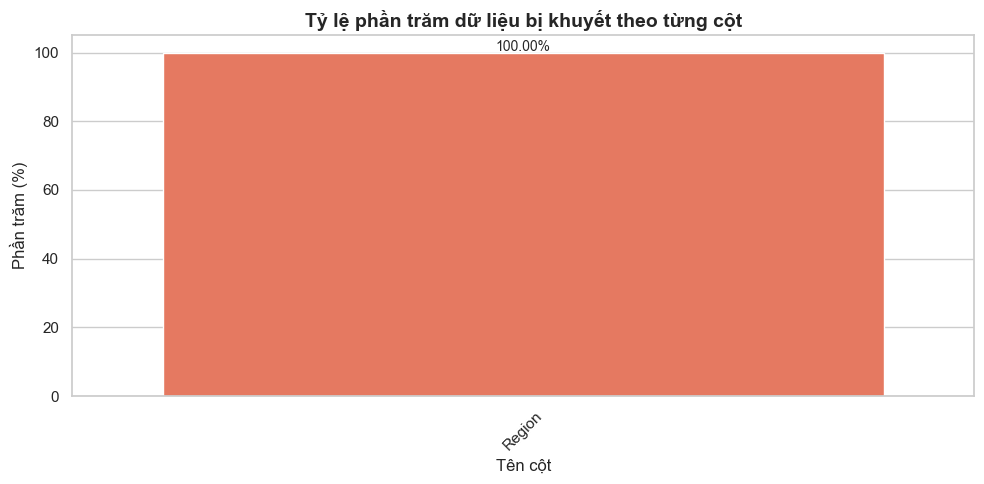

In [4]:
# Tính toán số lượng và phần trăm missing values
missing_data = df.isnull().sum()
missing_percent = (missing_data / len(df)) * 100

# Tạo một DataFrame để hiển thị đẹp hơn
missing_df = pd.DataFrame({
    'Số lượng Null': missing_data, 
    'Phần trăm (%)': missing_percent
})
missing_df = missing_df[missing_df['Số lượng Null'] > 0].sort_values(by='Phần trăm (%)', ascending=False)

print("BẢNG THỐNG KÊ DỮ LIỆU KHUYẾT:")
print(missing_df)

# Trực quan hóa bằng biểu đồ Bar Chart
if not missing_df.empty:
    plt.figure(figsize=(10, 5))
    sns.barplot(x=missing_df.index, y=missing_df['Phần trăm (%)'], palette='Reds_r')
    plt.title('Tỷ lệ phần trăm dữ liệu bị khuyết theo từng cột', fontsize=14, fontweight='bold')
    plt.ylabel('Phần trăm (%)', fontsize=12)
    plt.xlabel('Tên cột', fontsize=12)
    plt.xticks(rotation=45)
    
    # Thêm số % lên đầu mỗi cột
    for i, v in enumerate(missing_df['Phần trăm (%)']):
        plt.text(i, v + 0.5, f"{v:.2f}%", ha='center', fontsize=10)
        
    plt.tight_layout()
    plt.show()
else:
    print("Tuyệt vời! Tập dữ liệu không có giá trị khuyết nào.")


### Nhận xét về Tình trạng Dữ liệu Khuyết 

Dựa vào biểu đồ thống kê tỷ lệ dữ liệu khuyết ở trên, ta có thể rút ra một số kết luận quan trọng về chất lượng của bộ dữ liệu gốc:

1. **Chất lượng dữ liệu đo lường rất cao:** Tất cả các cột chứa chỉ số môi trường cốt lõi như `AQI`, `PM2.5`, `PM10`, `CO`, `NO2`,... đều có tỷ lệ missing là **0%**. Điều này cho thấy hệ thống cảm biến hoặc API thu thập dữ liệu hoạt động rất ổn định, không bị đứt quãng trong quá trình ghi nhận chuỗi thời gian.
2. **Khuyết 100% ở cột `Region`:** Duy nhất cột `Region` (Vùng miền) bị trống hoàn toàn. Nguyên nhân sâu xa là do bản chất của hệ thống API cung cấp dữ liệu không hỗ trợ khái niệm "vùng miền địa lý" đặc thù của Việt Nam (Miền Bắc, Trung, Nam). Cột này được cố ý chừa trống trong quá trình Data Collection.

**Hướng giải quyết:** 
Vì `Region` là một biến phân loại quan trọng để phục vụ phân tích tổng quan theo miền, ta không thể xóa cột này. Thay vào đó, ta sẽ sử dụng phương pháp **Feature Imputation bằng Domain Knowledge (Kiến thức chuyên ngành)**: Xây dựng một hàm ánh xạ để tự động điền giá trị `Region` tương ứng dựa vào tên của cột `Province` (Tỉnh/Thành).


## 3. Xử lý giá trị khuyết thiếu 
- Cột `Region` đang bị thiếu hàng loạt do lỗi thu thập. Ta sẽ tự động nội suy từ tên `Province` (Tỉnh/Thành).
- Điền các chỉ số đo lường bị thiếu bằng phương pháp nội suy.

In [5]:
# 2.1 Xử lý cột Region
mien_bac = ['Hà Nội', 'Hải Phòng', 'Bắc Ninh', 'Hà Giang', 'Cao Bằng', 'Bắc Kạn', 'Tuyên Quang', 'Lào Cai', 'Điện Biên', 'Lai Châu', 'Sơn La', 'Yên Bái', 'Hòa Bình', 'Thái Nguyên', 'Lạng Sơn', 'Quảng Ninh', 'Bắc Giang', 'Phú Thọ', 'Vĩnh Phúc', 'Hưng Yên', 'Hải Dương', 'Thái Bình', 'Hà Nam', 'Nam Định', 'Ninh Bình']
mien_trung = ['Thanh Hóa', 'Nghệ An', 'Hà Tĩnh', 'Quảng Bình', 'Quảng Trị', 'Thừa Thiên Huế', 'Đà Nẵng', 'Quảng Nam', 'Quảng Ngãi', 'Bình Định', 'Phú Yên', 'Khánh Hòa', 'Ninh Thuận', 'Bình Thuận', 'Kon Tum', 'Gia Lai', 'Đắk Lắk', 'Đắk Nông', 'Lâm Đồng']
# Các tỉnh còn lại coi như Miền Nam

def get_region(province):
    if pd.isna(province): return np.nan
    if province in mien_bac: return 'Miền Bắc'
    if province in mien_trung: return 'Miền Trung'
    return 'Miền Nam'

df['Region'] = df['Province'].apply(get_region)

# 2.2 Xử lý các chỉ số môi trường bị thiếu (Nội suy tuyến tính)
metrics = ['AQI', 'PM2.5 (g/m3)', 'PM10 (g/m3)', 'CO (g/m3)', 'NO2 (g/m3)', 'SO2 (g/m3)', 'O3 (g/m3)', 'Dust (g/m3)']

# Đổi tên cột cho chuẩn (loại bỏ ký tự lỗi)
df.columns = ['Timestamp', 'Code', 'Province', 'Region', 'AQI', 'PM2.5', 'PM10', 'CO', 'NO2', 'SO2', 'O3', 'Dust']
new_metrics = ['AQI', 'PM2.5', 'PM10', 'CO', 'NO2', 'SO2', 'O3', 'Dust']

# Nội suy dữ liệu theo từng tỉnh
print("Đang nội suy giá trị khuyết...")
df[new_metrics] = df.groupby('Province')[new_metrics].transform(lambda x: x.interpolate(method='linear').bfill().ffill())

print("Số lượng giá trị Null sau xử lý:")
print(df.isnull().sum())

Đang nội suy giá trị khuyết...
Số lượng giá trị Null sau xử lý:
Timestamp    0
Code         0
Province     0
Region       0
AQI          0
PM2.5        0
PM10         0
CO           0
NO2          0
SO2          0
O3           0
Dust         0
dtype: int64


## 4. Xử lý giá trị bất thường (Outliers)
- **Lỗi cảm biến âm:** Bất kỳ nồng độ hóa chất nào < 0 đều là phi vật lý. Sẽ được gán về 0.
- **Giá trị nhiễu đột biến:** Nếu AQI > 500 (Ngưỡng nguy hại tuyệt đối) thường do cảm biến hỏng. Ta sẽ chặn (clip) hoặc lọc bỏ.

--- BÁO CÁO XỬ LÝ OUTLIERS ---
  + Không phát hiện giá trị âm nào trong các chỉ số đo lường.
  + Cột AQI: Phát hiện 0 giá trị > 500 -> Đã chặn ở mức tối đa (500).
------------------------------


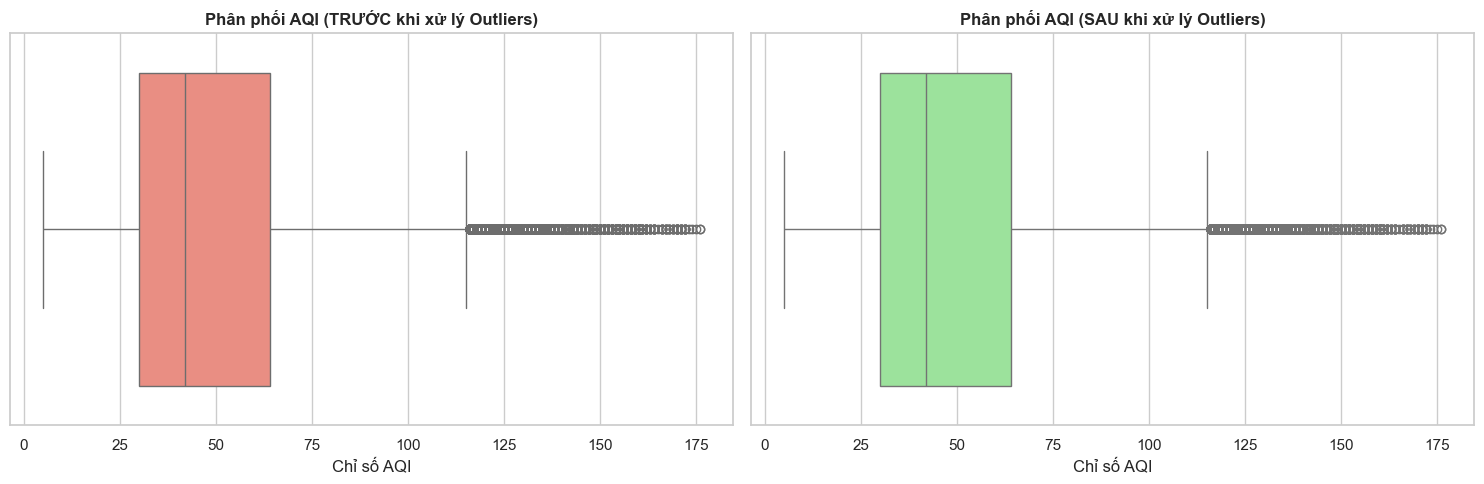

Giá trị AQI lớn nhất hiện tại: 176
Giá trị AQI nhỏ nhất hiện tại: 5


In [6]:
# Tạo Figure với 2 biểu đồ (Subplots) đặt cạnh nhau
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# --- BIỂU ĐỒ 1: TRƯỚC KHI XỬ LÝ ---
sns.boxplot(x=df['AQI'], ax=axes[0], color='salmon')
axes[0].set_title('Phân phối AQI (TRƯỚC khi xử lý Outliers)', fontweight='bold')
axes[0].set_xlabel('Chỉ số AQI')

# --- ĐẾM SỐ LƯỢNG TRƯỚC KHI XỬ LÝ ---
print("--- BÁO CÁO XỬ LÝ OUTLIERS ---")

# 1. Đếm và xử lý giá trị âm
total_negatives = 0
for col in new_metrics:
    # Đếm số lượng giá trị < 0
    neg_count = (df[col] < 0).sum()
    if neg_count > 0:
        print(f"  + Cột {col}: Phát hiện {neg_count} giá trị âm -> Đã ép về 0.")
        total_negatives += neg_count
    
    # Thực hiện ép về 0
    df[col] = df[col].apply(lambda x: 0 if x < 0 else x)

if total_negatives == 0:
    print("  + Không phát hiện giá trị âm nào trong các chỉ số đo lường.")

# 2. Đếm và xử lý AQI > 500
aqi_capped_count = (df['AQI'] > 500).sum()
print(f"  + Cột AQI: Phát hiện {aqi_capped_count} giá trị > 500 -> Đã chặn ở mức tối đa (500).")

# Thực hiện chặn trần ở mức 500
df['AQI'] = df['AQI'].clip(upper=500)

print("-" * 30)


# --- BIỂU ĐỒ 2: SAU KHI XỬ LÝ ---
sns.boxplot(x=df['AQI'], ax=axes[1], color='lightgreen')
axes[1].set_title('Phân phối AQI (SAU khi xử lý Outliers)', fontweight='bold')
axes[1].set_xlabel('Chỉ số AQI')

plt.tight_layout()
plt.show()

# Kiểm tra lại max/min
print(f"Giá trị AQI lớn nhất hiện tại: {df['AQI'].max()}")
print(f"Giá trị AQI nhỏ nhất hiện tại: {df['AQI'].min()}")


## 5. Kỹ thuật Đặc trưng 
Dữ liệu của chúng ta là chuỗi thời gian (Time-series). Việc để nguyên cột `Timestamp` dưới dạng chuỗi (String) sẽ rất khó phân tích. Ta cần chuyển nó về chuẩn `datetime` và tách ra các cột như `Year`, `Month`, `Day`, `Hour`, `DayOfWeek` để phục vụ cho các biểu đồ phân tích xu hướng ở Notebook tiếp theo.


In [8]:
# 5.1 Chuyển đổi kiểu dữ liệu
df['Timestamp'] = pd.to_datetime(df['Timestamp'])

# 5.2 Trích xuất các đặc trưng thời gian
df['Year'] = df['Timestamp'].dt.year
df['Month'] = df['Timestamp'].dt.month
df['Day'] = df['Timestamp'].dt.day
df['Hour'] = df['Timestamp'].dt.hour
df['DayOfWeek'] = df['Timestamp'].dt.dayofweek # 0=Thứ 2, 6=Chủ Nhật

# 5.3 Tính toán thêm Level của AQI (Nếu cần)
# Phân loại AQI theo chuẩn (Tốt, Trung bình, Kém, Xấu, Rất Xấu, Nguy Hại)
def get_aqi_level(aqi):
    if aqi <= 50: return 'Tốt'
    elif aqi <= 100: return 'Trung Bình'
    elif aqi <= 150: return 'Kém'
    elif aqi <= 200: return 'Xấu'
    elif aqi <= 300: return 'Rất Xấu'
    else: return 'Nguy Hại'

df['AQI_Level'] = df['AQI'].apply(get_aqi_level)

print("Đã thêm thành công các cột thời gian và AQI Level!")
print(df[['Timestamp', 'Year', 'Month', 'Day', 'Hour', 'DayOfWeek', 'AQI', 'AQI_Level']].head()) if 'display' in globals() else print(df[['Timestamp', 'Year', 'Month', 'Day', 'Hour', 'DayOfWeek', 'AQI', 'AQI_Level']].head())


Đã thêm thành công các cột thời gian và AQI Level!
            Timestamp  Year  Month  Day  Hour  DayOfWeek  AQI   AQI_Level
0 2024-01-01 00:00:00  2024      1    1     0          0   57  Trung Bình
1 2024-01-01 01:00:00  2024      1    1     1          0   56  Trung Bình
2 2024-01-01 02:00:00  2024      1    1     2          0   55  Trung Bình
3 2024-01-01 03:00:00  2024      1    1     3          0   54  Trung Bình
4 2024-01-01 04:00:00  2024      1    1     4          0   51  Trung Bình


## 6. Lưu dữ liệu sạch
Cuối cùng, lưu DataFrame đã làm sạch và thêm đặc trưng vào thư mục `data/cleaned/` để chuẩn bị cho bước Exploratory Data Analysis (EDA) và Import vào Database.


In [9]:
output_path = '../data/cleaned/vietnam_air_quality_dataset_cleaned.csv'
df.to_csv(output_path, index=False, encoding='utf-8-sig')

print(f"🎉 HOÀN TẤT! Dữ liệu sạch đã được lưu tại: {output_path}")
print(f"Tổng số dòng: {len(df)}")
print(f"Tổng số cột: {len(df.columns)}")


🎉 HOÀN TẤT! Dữ liệu sạch đã được lưu tại: ../data/cleaned/vietnam_air_quality_dataset_cleaned.csv
Tổng số dòng: 1388016
Tổng số cột: 18
